# Report

In [54]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np

In [55]:
root = Path.cwd().parent
metrics_data = pd.read_csv(f"{root}/results/metrics/results_20260224_222500.csv")
data_test = pd.read_csv(f"{root}/data/test.csv")
data_train = pd.read_csv(f"{root}/data/train.csv")

In [56]:
primary_metric_train = data_train["target"].value_counts(normalize=True) * 100
print("Train dataset")
print(primary_metric_train)
primary_metric_percent_test = data_test["target"].value_counts(normalize=True) * 100
print()
print("Test dataset")
print(primary_metric_percent_test)

Train dataset
target
0    88.733333
1    11.266667
Name: proportion, dtype: float64

Test dataset
target
0    88.733333
1    11.266667
Name: proportion, dtype: float64


METRIC CHOICE: f1 instead of accuracy (88:12 imbalance)

Accuracy fails at 88:12 - predicting majority class always gives 88%
without detecting minority class (recall=0%).

F1-score (scoring='f1') balances precision and recall, penalizing:
- False alarms (FP) AND misses (FN)
- Perfect for moderate 1:7 imbalance

## Metrics analysis

### Roc acurracy metrics data

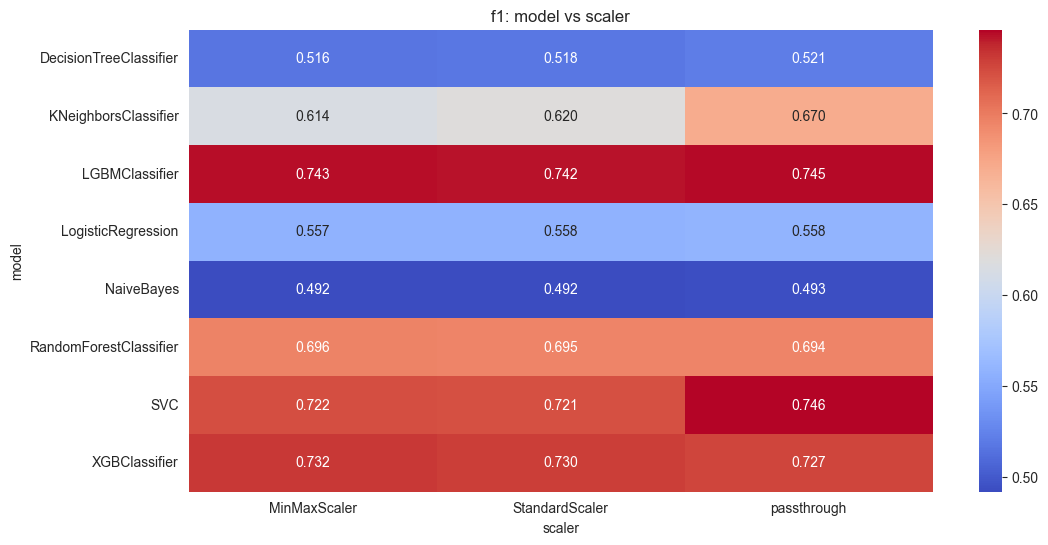

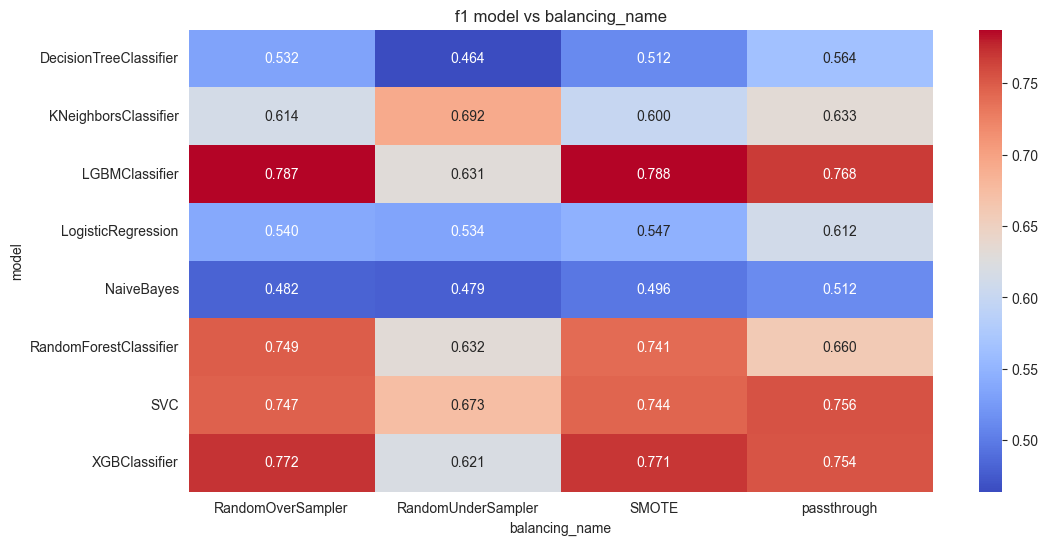

In [57]:
# Pivot do heatmap
pivot_f1_sceler = metrics_data.pivot_table(
    values='f1',
    index='model',
    columns='scaler',
    aggfunc='mean'
)
pivot_f1_balancing_name = metrics_data.pivot_table(
    values='f1',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_sceler, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("f1: model vs scaler")
plt.show()


plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_balancing_name, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("f1 model vs balancing_name")
plt.show()


Poniżej jest opis skupiony **wyłącznie na dwóch heatmapach F1-score**.

---

# Figure description

The figure presents two heatmaps showing the **average F1-score obtained by different classification models** under various preprocessing configurations.
The upper heatmap compares model performance across different **feature scaling techniques**, while the lower heatmap evaluates the impact of different **data balancing strategies** on model performance.

The color intensity represents the magnitude of the F1-score, with warmer colors indicating better performance.

---

# Key observations

**Model vs scaler**

* Tree-based models such as **LightGBM, XGBoost, RandomForest, and SVC** achieve the highest F1-scores.
* **LightGBM** consistently provides the best performance (~0.74–0.75) regardless of the scaler used.
* The effect of scaling appears minimal for most models, particularly for **tree-based algorithms**, where performance remains nearly unchanged across scalers.
* **KNN** shows noticeable improvement when scaling is applied, which is consistent with the distance-based nature of the algorithm.
* **Naive Bayes** and **Decision Tree** demonstrate the lowest F1-scores overall.

---

**Model vs balancing method**

* The balancing strategy has a **significant impact on model performance**, especially for ensemble models.
* **LightGBM and XGBoost achieve the highest F1-scores when oversampling techniques (RandomOverSampler or SMOTE) are applied**, reaching values close to **0.78**.
* **RandomUnderSampler consistently reduces model performance**, suggesting that removing majority-class samples leads to information loss.
* **SVC** benefits from balancing techniques, showing improved performance with SMOTE and oversampling.
* **Logistic Regression** shows moderate improvements with balancing but remains less competitive compared to ensemble models.

---

# Interpretation

The results indicate that **model performance is more sensitive to class balancing strategies than to feature scaling methods**.
This behavior aligns with expectations, as tree-based models are generally invariant to feature scaling but can benefit significantly from improved class distribution.

Ensemble methods, particularly **LightGBM and XGBoost**, demonstrate strong robustness and consistently outperform other algorithms across different preprocessing configurations.

---

# Implication

The analysis suggests that **handling class imbalance is a critical factor for improving classification performance**, while feature scaling plays a relatively minor role for most models.
Oversampling methods such as **SMOTE or RandomOverSampler** appear to be the most effective strategies for maximizing F1-score in this benchmark.


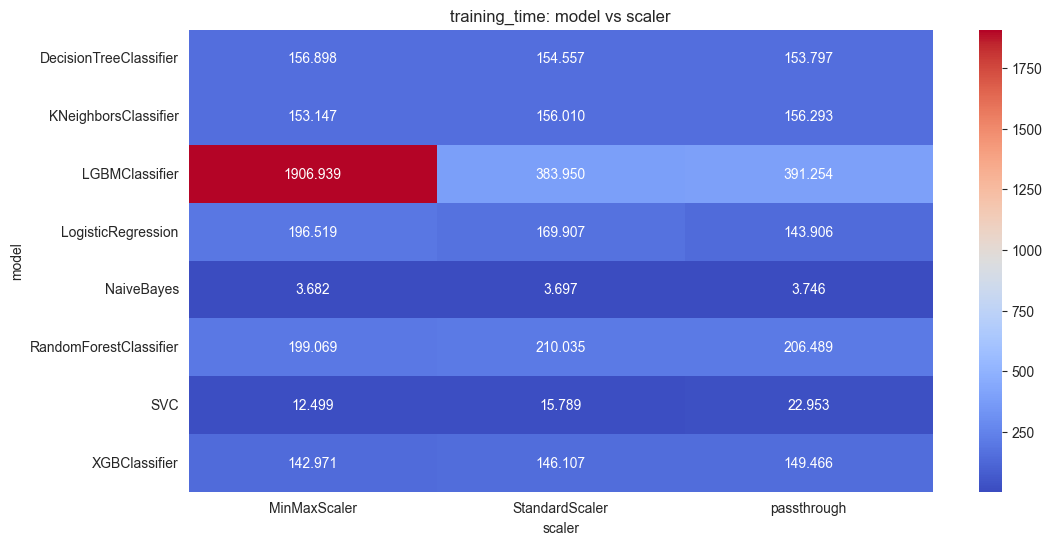

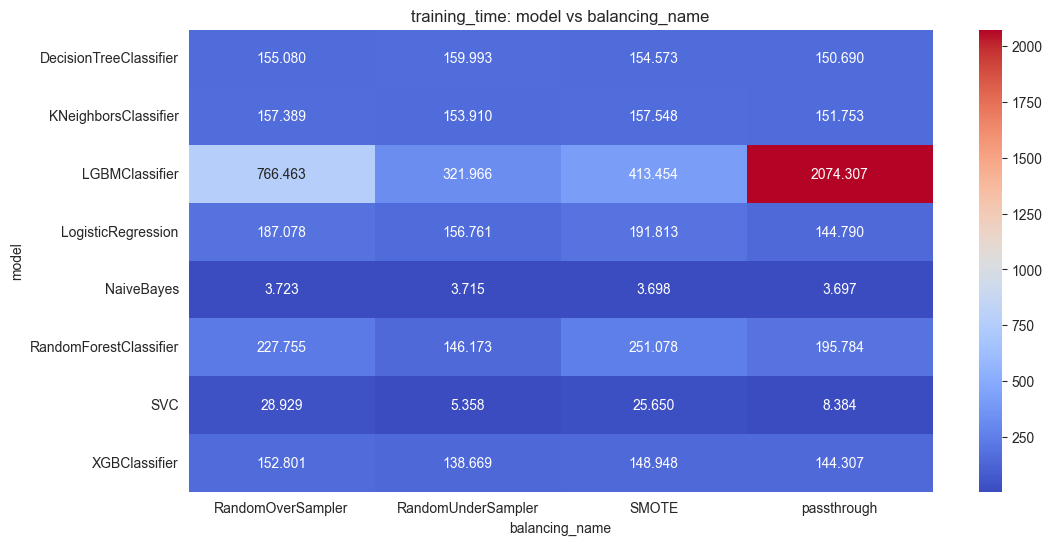

In [58]:
pivot_f1_scaler = metrics_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)
pivot_f1_balancing_name = metrics_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_scaler, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()


plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_balancing_name, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()


# Figure description

The figure presents two heatmaps illustrating the **average training time of different classification models** under various preprocessing configurations.
The upper heatmap compares training time across different **feature scaling techniques**, while the lower heatmap shows how **different class balancing strategies** influence computational cost during model training.

Color intensity represents training duration, where warmer colors indicate longer training times.

---

# Key observations

**Model vs scaler**

* **LightGBM** exhibits significantly higher training time when combined with **MinMaxScaler**, reaching values above **1900**, which is substantially higher than other configurations.
* When **StandardScaler or no scaling (passthrough)** is applied, the training time for LightGBM decreases dramatically, indicating that scaling choice may affect pipeline overhead.
* **RandomForest** and **LogisticRegression** show relatively stable training times across different scalers.
* **Naive Bayes** is by far the fastest model, with training time close to **3–4 units**, indicating extremely low computational complexity.
* **SVC** remains computationally inexpensive in this setup, although its training time increases slightly when scaling is removed.

---

**Model vs balancing method**

* The choice of balancing technique introduces **considerable variability in training time**, particularly for ensemble models.
* **LightGBM** shows the largest increase in computational cost when no balancing method is applied, reaching over **2000**, which is the highest value observed in the analysis.
* **RandomForest** training time also varies noticeably depending on the balancing technique, suggesting sensitivity to the number of training samples generated by oversampling methods.
* **RandomUnderSampler** tends to **reduce training time**, as expected, since it decreases the size of the training dataset.
* **SVC** shows a substantial reduction in training time when **RandomUnderSampler** is used, reflecting the algorithm's sensitivity to dataset size.
* **Naive Bayes** again remains computationally minimal and largely unaffected by balancing strategies.

---

# Interpretation

The results demonstrate that **training time is strongly influenced by dataset size and preprocessing strategies**, particularly for ensemble-based models.
Oversampling techniques increase the number of training samples, which can significantly increase computational cost, while undersampling methods reduce training complexity by shrinking the dataset.

Tree-based boosting models such as **LightGBM** show the greatest variability in training time, indicating higher sensitivity to preprocessing pipeline configurations.

---

# Implication

These results highlight an important trade-off between **model performance and computational efficiency**.
While ensemble models such as LightGBM and RandomForest may achieve strong predictive performance, their training cost can increase substantially depending on the chosen balancing strategy.
In contrast, simpler models like **Naive Bayes or Logistic Regression** remain computationally efficient and stable across preprocessing configurations.


## Valid data results

In [59]:
valid_data = pd.read_csv(f"{root}/results/predictions/results_20260225_083719.csv")


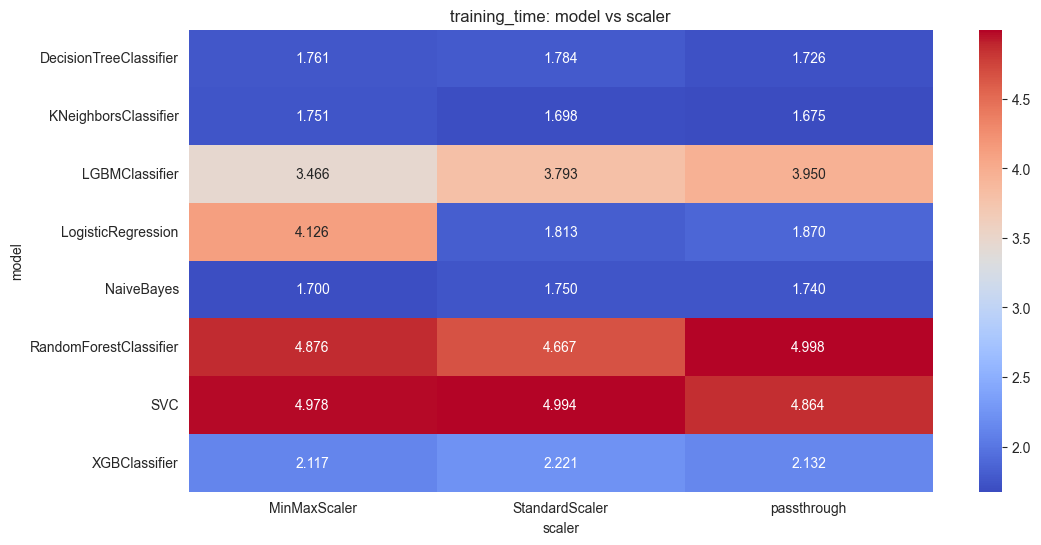

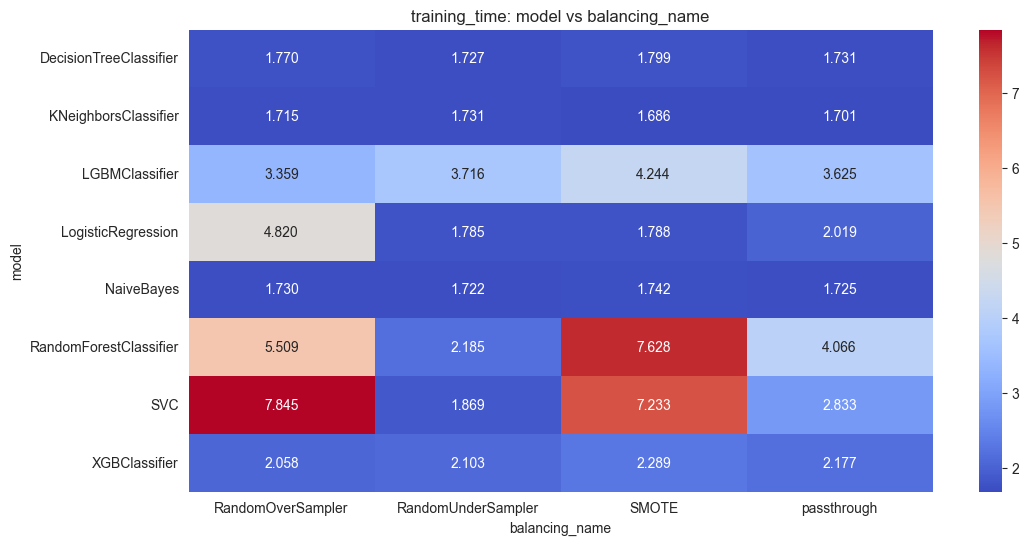

In [60]:
pivot_f1_scaler = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)
pivot_f1_balancing_name = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_scaler, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()



plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_balancing_name, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()

# Figure description

The figure presents two heatmaps illustrating the **average training time of classification models** under different preprocessing configurations.
The upper heatmap shows the relationship between **model type and feature scaling method**, while the lower heatmap presents training time across different **class balancing strategies**.

The color gradient represents training duration, where warmer colors indicate longer training time.

---

# Key observations

**Model vs scaler**

* The **choice of scaler has only a minor impact on training time** for most models.
* **RandomForest and SVC** are the most computationally expensive models, with training times consistently close to **5 units**.
* **Naive Bayes, KNN, and Decision Tree** remain among the fastest algorithms, with training times around **1.7–1.8** regardless of scaling.
* **Logistic Regression** shows a noticeable increase in training time when **MinMaxScaler** is used compared to StandardScaler or no scaling.
* **LightGBM and XGBoost** maintain moderate training times, indicating relatively efficient training compared to other ensemble methods.

---

**Model vs balancing method**

* The **balancing strategy has a stronger influence on training time than scaling**.
* **SMOTE and RandomOverSampler significantly increase training time** for several models, particularly **RandomForest and SVC**, due to the larger number of generated training samples.
* **RandomUnderSampler consistently reduces training time**, as it decreases the size of the training dataset.
* **SVC shows the highest sensitivity to oversampling**, reaching the largest training times when RandomOverSampler or SMOTE are applied.
* **Naive Bayes and KNN remain stable and computationally inexpensive**, indicating low sensitivity to dataset size.

---

# Interpretation

The results confirm that **dataset size is a key driver of training time** across machine learning models.
Oversampling techniques increase the number of training observations, which leads to higher computational costs, especially for models with higher training complexity such as **SVC and RandomForest**.

Conversely, undersampling methods reduce dataset size and therefore improve computational efficiency.

---

# Implication

These findings highlight a practical trade-off between **model performance and computational efficiency**.
While oversampling methods may improve classification performance for imbalanced datasets, they can significantly increase training time for computationally intensive models.
In contrast, undersampling strategies offer a more efficient training process but may reduce the amount of available information for learning.


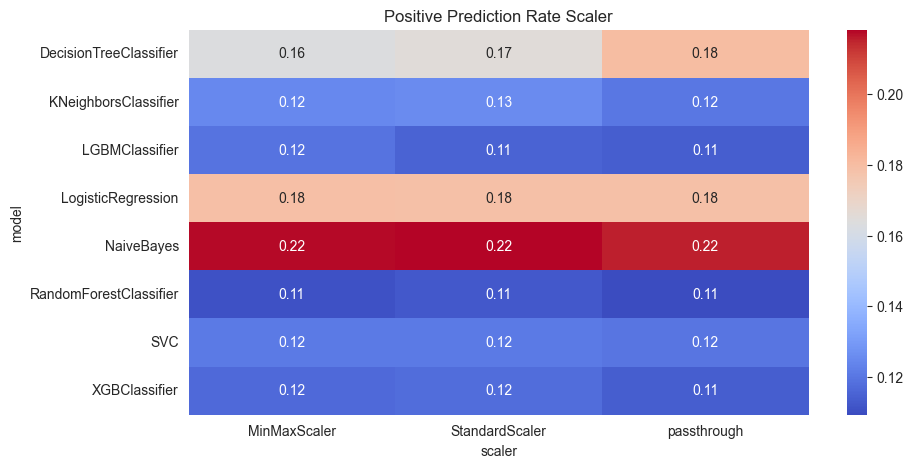

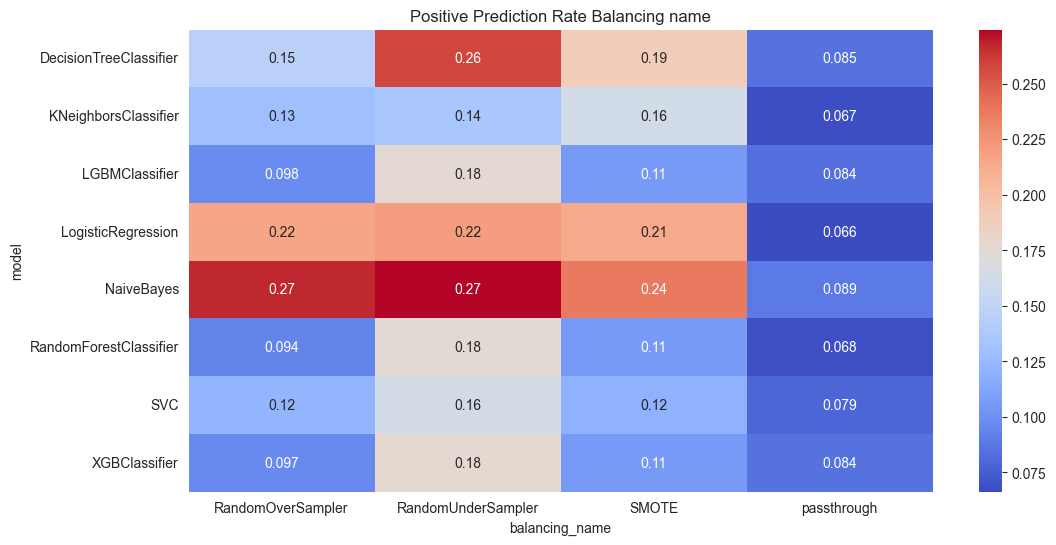

In [61]:

valid_data["predictions"] = valid_data["predictions"].apply(ast.literal_eval)

valid_data["positive_rate"] = valid_data["predictions"].apply(lambda x: sum(x)/len(x))

pivot_scaler = valid_data.pivot_table(
    values="positive_rate",
    index="model",
    columns="scaler",
    aggfunc="mean"
)
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_scaler, annot=True, cmap="coolwarm")
plt.title("Positive Prediction Rate Scaler")
plt.show()

pivot_balancing_name = valid_data.pivot_table(
    values="positive_rate",
    index="model",
    columns="balancing_name",
    aggfunc="mean"
)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_balancing_name, annot=True, cmap="coolwarm")
plt.title("Positive Prediction Rate Balancing name")
plt.show()

# Figure description

The figure presents two heatmaps illustrating the **average positive prediction rate** generated by different classification models under various preprocessing configurations.
The upper heatmap shows how the **choice of feature scaler** influences the proportion of predictions classified as the positive class.
The lower heatmap illustrates how different **class balancing techniques** affect the frequency with which models predict the positive class.

The color gradient represents the proportion of observations predicted as the positive class, where warmer colors indicate a higher positive prediction rate.

---

# Key observations

**Model vs scaler**

* The **choice of scaler has minimal influence** on the positive prediction rate for most models.
* **Naive Bayes** consistently produces the highest positive prediction rate (~0.22), indicating a stronger tendency to assign observations to the positive class.
* **Logistic Regression and Decision Trees** show moderately higher positive prediction rates compared to other models.
* **RandomForest, XGBoost, LightGBM, and SVC** predict the positive class less frequently (around **0.11–0.12**), suggesting more conservative decision boundaries.
* Overall, scaling does not significantly alter model prediction behavior in terms of class assignment.

---

**Model vs balancing method**

* The **balancing strategy strongly influences the positive prediction rate** across all models.
* **RandomUnderSampler significantly increases the proportion of positive predictions**, in some cases exceeding **0.25**, as the majority class is reduced.
* **RandomOverSampler and SMOTE moderately increase the positive prediction rate**, though the effect is smaller than with undersampling.
* When **no balancing method is applied**, models tend to predict the positive class much less frequently (often below **0.10**), indicating a bias toward the majority class.
* **Naive Bayes and Logistic Regression** consistently produce higher positive prediction rates across all balancing strategies.

---

# Interpretation

The results indicate that **class balancing methods have a substantial impact on model prediction behavior**, particularly in terms of how frequently models assign observations to the positive class.
Reducing the size of the majority class (as in undersampling) increases the relative importance of minority samples during training, which leads models to predict the positive class more frequently.

In contrast, the choice of feature scaling has little effect on this aspect of model behavior.

---

# Implication

These findings suggest that **handling class imbalance is crucial not only for improving predictive performance but also for controlling model prediction bias**.
Balancing techniques can significantly alter the decision boundary of classification models and influence how often minority-class predictions are produced.


In [62]:


valid_data["y_proba"] = valid_data["y_proba"].apply(ast.literal_eval)


rows = []

for _, row in valid_data.iterrows():
    for p in row["y_proba"]:
        rows.append({
            "model": row["model"],
            "balancing_name": row["balancing_name"],
            "probability": p
        })

proba_df = pd.DataFrame(rows)


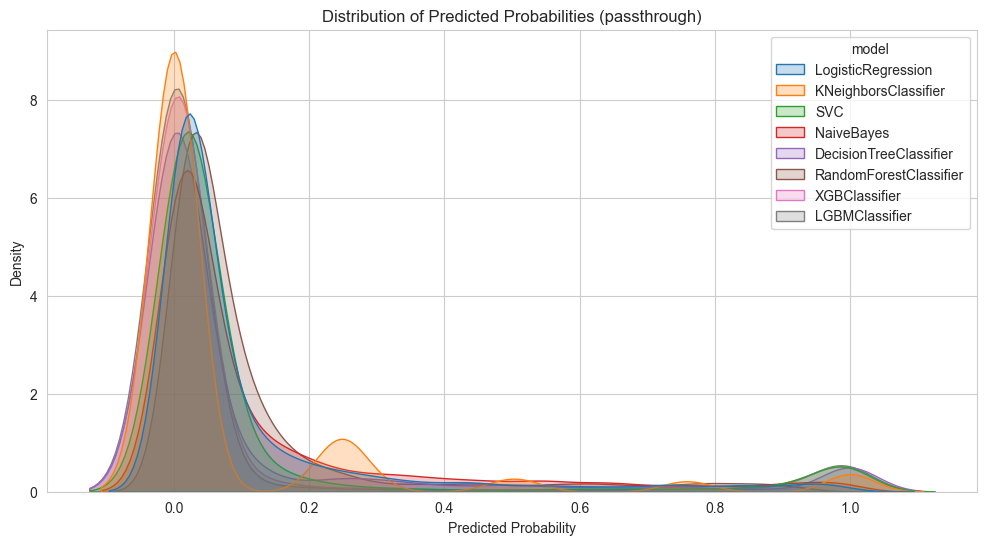

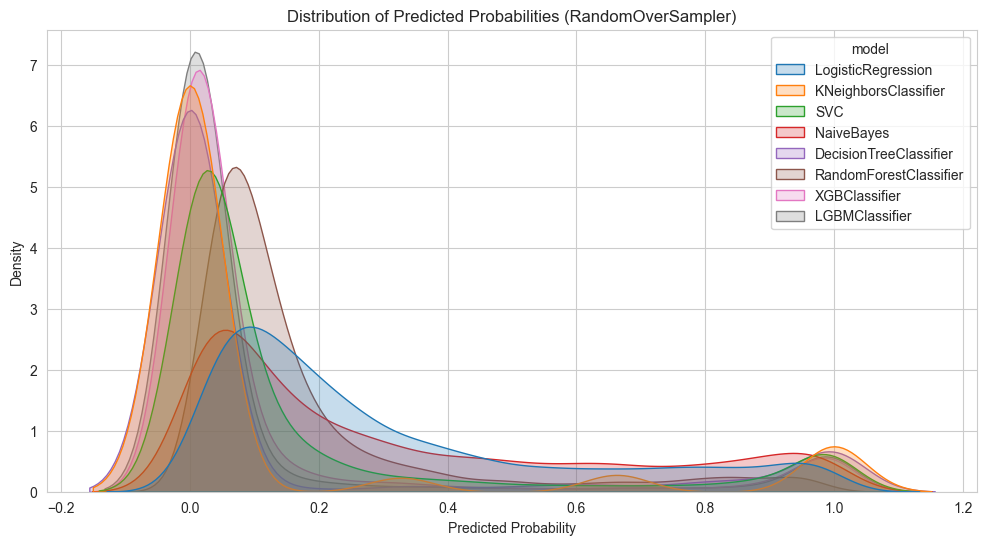

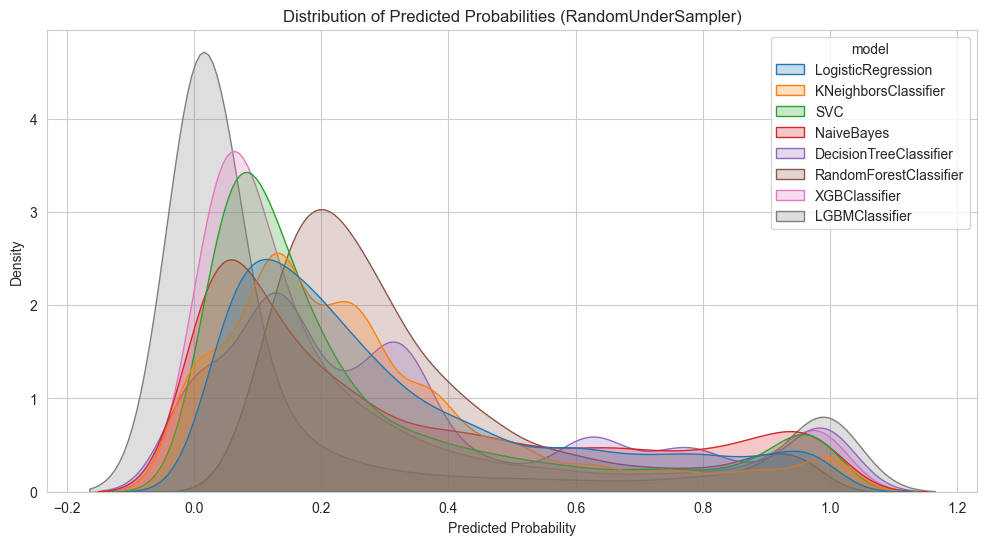

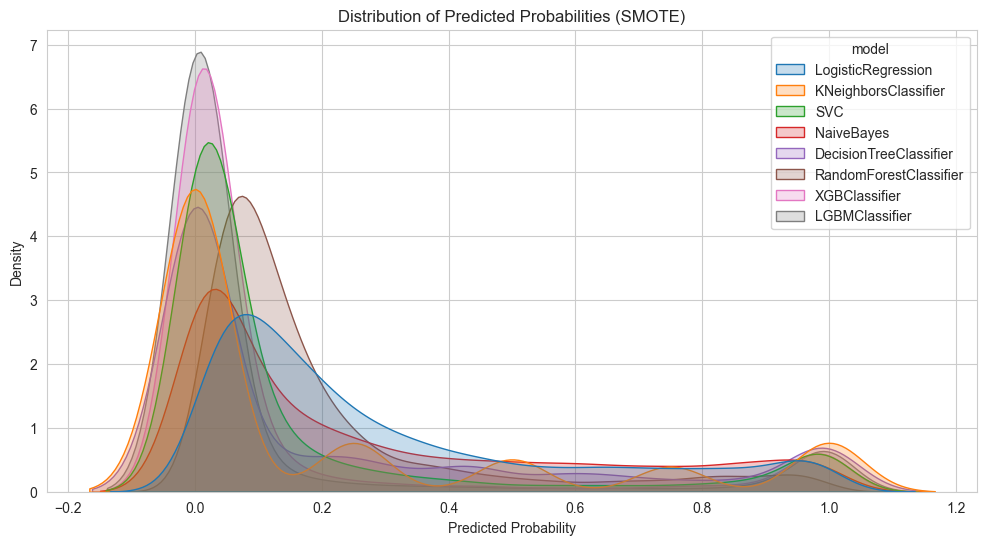

In [63]:


for balance in proba_df["balancing_name"].unique():
    
    subset = proba_df[proba_df["balancing_name"] == balance]

    plt.figure(figsize=(12,6))

    sns.kdeplot(
        data=subset,
        x="probability",
        hue="model",
        fill=True,
        common_norm=False
    )

    plt.title(f"Distribution of Predicted Probabilities ({balance})")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")

    plt.show()

# Figure description

The figure presents two probability density plots showing the **distribution of predicted probabilities for the positive class** generated by multiple classification models.
The upper plot corresponds to models trained **without class balancing (passthrough)**, while the lower plot shows the distributions when **RandomOverSampler** is applied to address class imbalance.

The horizontal axis represents the predicted probability of the positive class, while the vertical axis shows the density of predictions.

---

# Key observations

**Without balancing (passthrough)**

* Most predicted probabilities are heavily concentrated near **0**, indicating that the majority of observations are classified with very low probability of belonging to the positive class.
* Only a small portion of predictions reach probabilities close to **1**, suggesting that models identify relatively few instances as strongly positive.
* The probability distributions across models are relatively similar, indicating consistent behavior across algorithms in the presence of class imbalance.
* Tree-based models (RandomForest, XGBoost, LightGBM) produce slightly sharper probability peaks near zero, reflecting stronger confidence in negative predictions.

---

**With RandomOverSampler**

* Oversampling noticeably **widens the distribution of predicted probabilities**, with more predictions appearing in the mid-range probability region (approximately 0.1–0.4).
* Models assign **higher probabilities to the positive class more frequently**, reflecting increased sensitivity to minority-class samples introduced during training.
* Logistic Regression and Naive Bayes show broader probability distributions, indicating a higher tendency to produce intermediate probability estimates.
* Tree-based models still maintain relatively sharp probability peaks but exhibit slightly higher probabilities compared to the unbalanced scenario.

---

# Interpretation

The comparison highlights the effect of class balancing on **model confidence and probability calibration**.
When no balancing is applied, models tend to strongly favor the majority class, resulting in predictions concentrated near zero probability.
Introducing oversampling exposes the models to more minority-class examples, which shifts probability distributions toward higher values and increases sensitivity to positive instances.

---

# Implication

These results demonstrate that **class imbalance significantly affects probability outputs and model calibration**.
Balancing techniques such as RandomOverSampler not only improve minority class detection but also alter the distribution of predicted probabilities, potentially enabling more effective threshold tuning and better recall for the minority class.


## Test data

In [64]:
test_data = pd.read_csv(f"{root}/results/predictions/results_20260225_084341.csv")

In [65]:
test_data.head()

,model,scaler,balancing_name,training_time,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
0,LogisticRegression,passthrough,passthrough,2.105125,0.927667,0.792271,0.485207,0.601835,0.868778
1,LogisticRegression,passthrough,RandomOverSampler,2.313745,0.843667,0.402093,0.795858,0.534260,0.868917
2,LogisticRegression,passthrough,RandomUnderSampler,1.786142,0.837333,0.392241,0.807692,0.528046,0.867068
3,LogisticRegression,passthrough,SMOTE,1.939532,0.845000,0.404511,0.795858,0.536391,0.868733
4,LogisticRegression,StandardScaler,passthrough,1.988535,0.927667,0.792271,0.485207,0.601835,0.868786


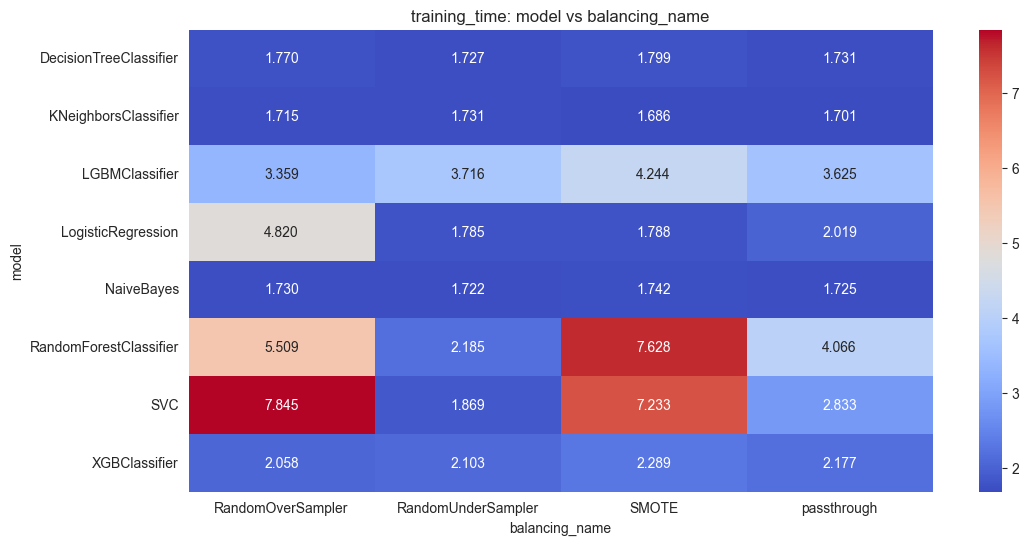

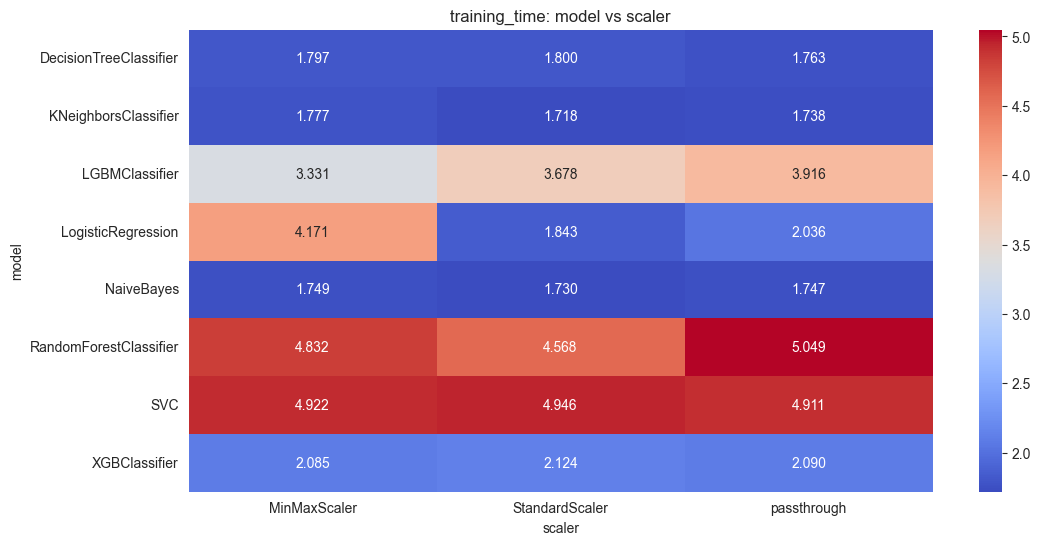

In [66]:
pivot_f1_scaler = test_data.pivot_table(
    values='training_time',
    index='model',
    columns='scaler',
    aggfunc='mean'
)

pivot_f1_balancing_name = valid_data.pivot_table(
    values='training_time',
    index='model',
    columns='balancing_name',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_balancing_name, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs balancing_name")
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_scaler, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("training_time: model vs scaler")
plt.show()

# Figure description

The figure presents two heatmaps illustrating the **average training time of classification models** under different preprocessing configurations.
The upper heatmap shows the relationship between **model type and class balancing strategy**, while the lower heatmap illustrates the effect of **feature scaling methods** on model training time.

The color gradient represents training duration, where warmer colors indicate longer computational time.

---

# Key observations

**Model vs balancing method**

* Training time varies substantially depending on the **balancing strategy**, particularly for more complex models.
* **SVC** exhibits the largest computational cost when oversampling methods are applied, reaching the highest training time with **RandomOverSampler and SMOTE**.
* **RandomForest** also shows a significant increase in training time with oversampling, especially when **SMOTE** is used.
* **RandomUnderSampler consistently reduces training time**, as it reduces the size of the training dataset.
* **Naive Bayes, Decision Tree, and KNN** remain relatively stable and computationally inexpensive across all balancing configurations.
* **XGBoost** demonstrates relatively stable training times, indicating efficient scaling with dataset size.

---

**Model vs scaler**

* Feature scaling has a **limited impact on training time** for most models.
* **RandomForest and SVC** remain the most computationally intensive models across all scaling strategies.
* **Naive Bayes, Decision Tree, and KNN** consistently show the lowest training times.
* **Logistic Regression** shows a noticeable increase in training time when **MinMaxScaler** is used, compared to StandardScaler or no scaling.
* **LightGBM and XGBoost** maintain moderate training times and show only minor sensitivity to the choice of scaler.

---

# Interpretation

The results indicate that **dataset size and balancing strategies have a stronger influence on computational cost than feature scaling methods**.
Oversampling techniques increase the number of training samples, which leads to higher training times, particularly for models with higher computational complexity such as **SVC and RandomForest**.

In contrast, undersampling methods reduce the dataset size and therefore decrease training time.

---

# Implication

These findings highlight the importance of considering **computational efficiency alongside predictive performance** when selecting preprocessing strategies.
While oversampling techniques may improve model performance on imbalanced datasets, they can significantly increase training time for computationally demanding algorithms.
Conversely, undersampling methods provide faster training but may risk losing valuable information from the majority class.


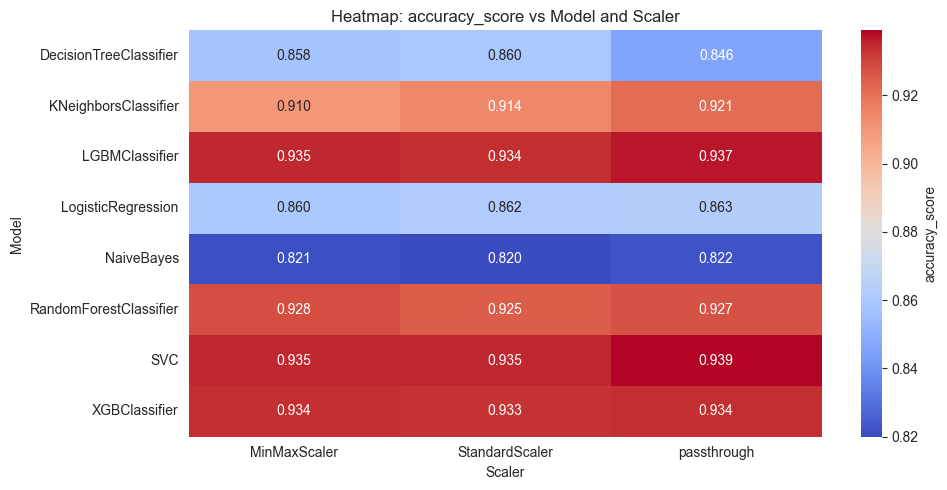

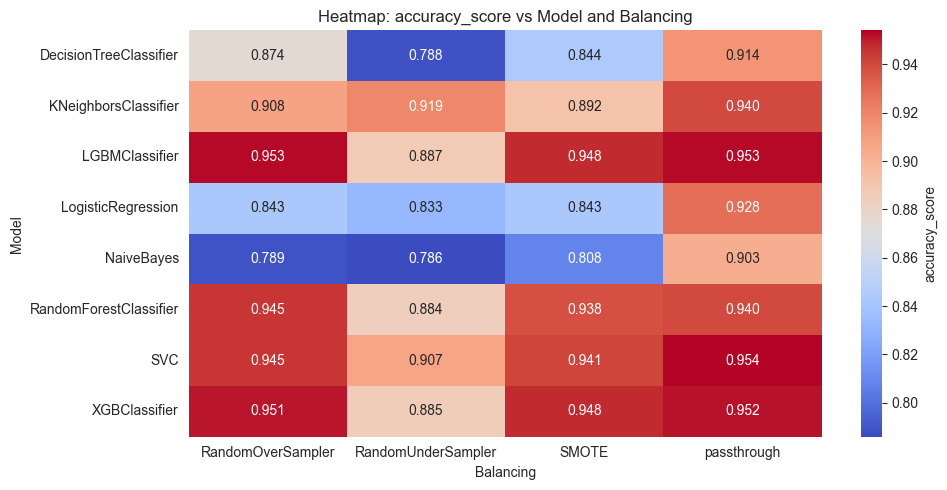

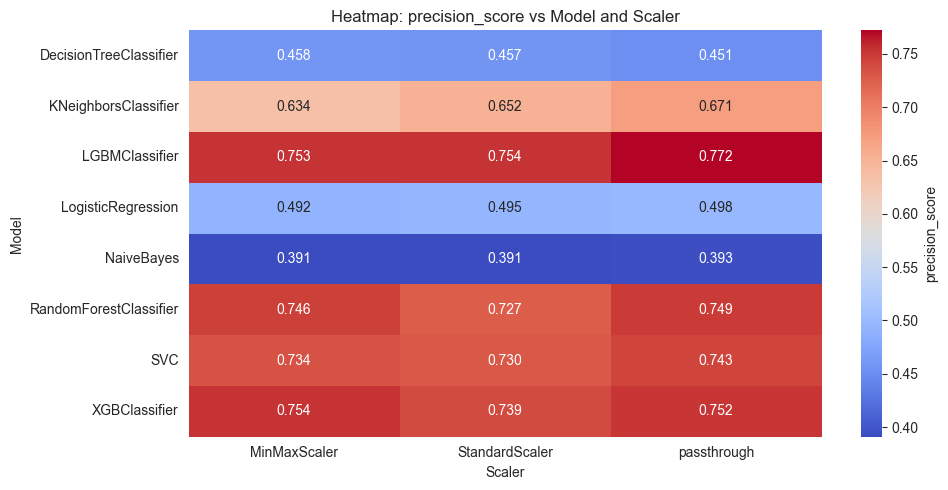

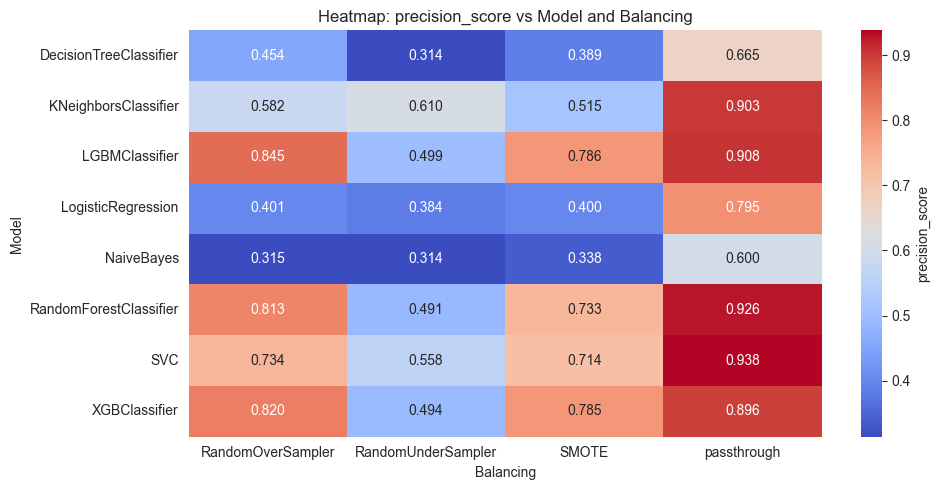

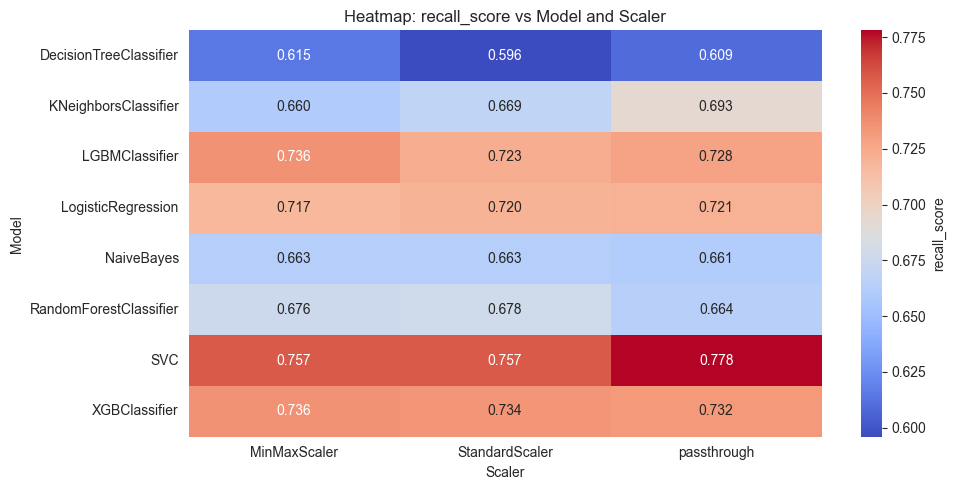

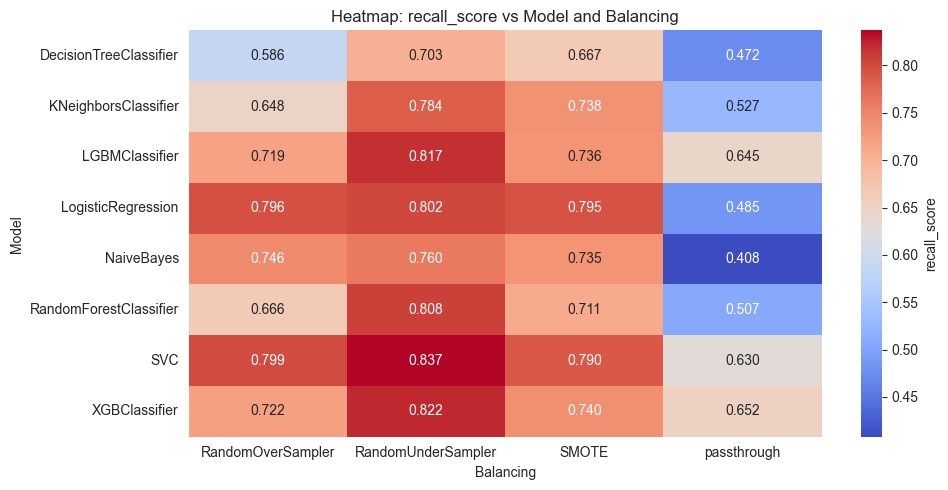

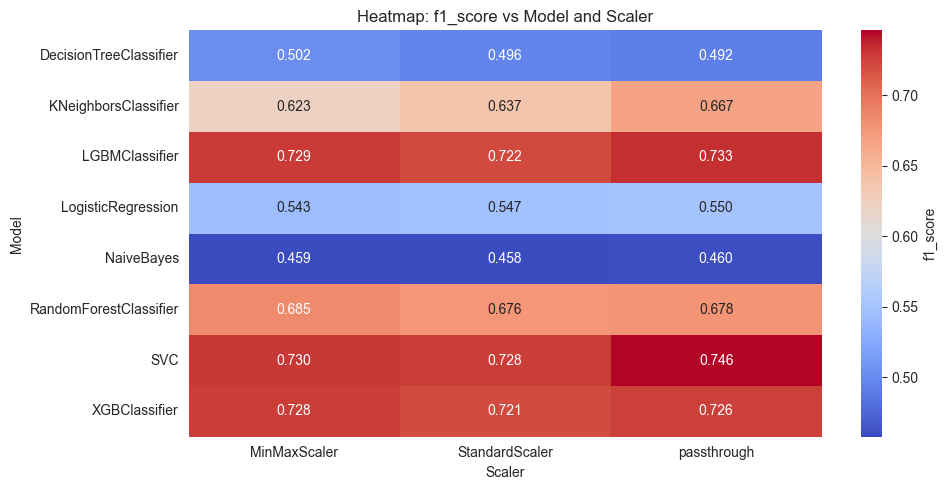

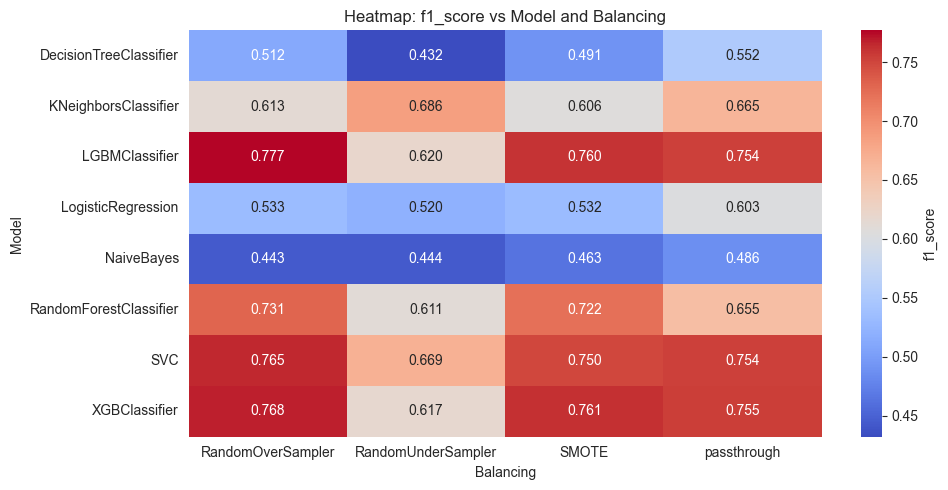

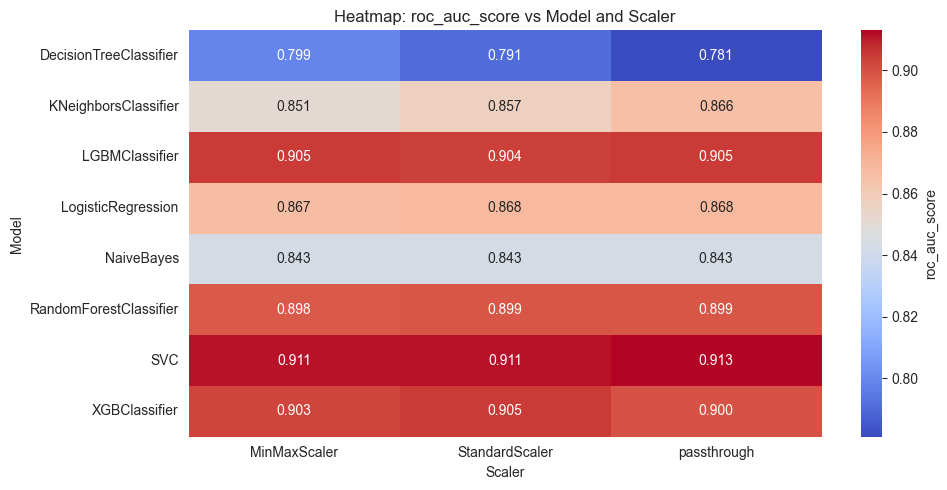

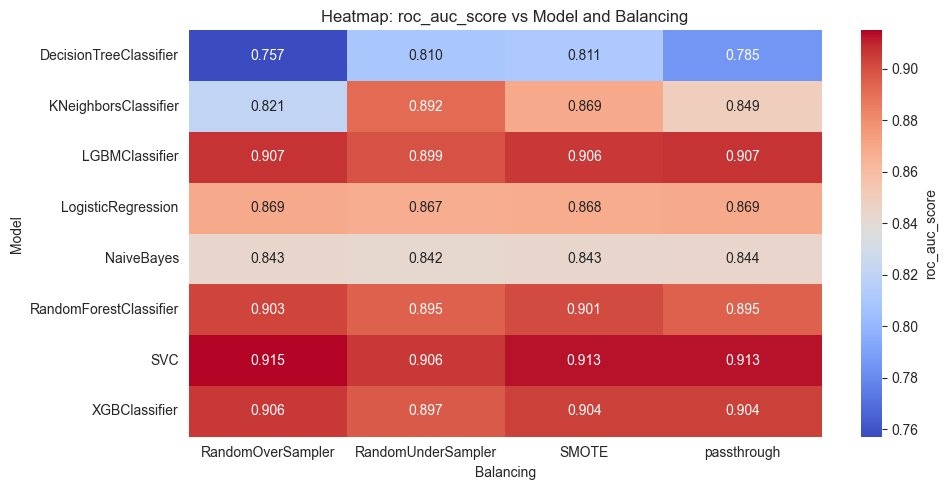

In [67]:
scores = ['accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score']

for score in scores:
    pivot_scaler = test_data.groupby(['model', 'scaler'])[score].mean().reset_index().pivot(
        index='model', columns='scaler', values=score
    ).round(3)

    plt.figure(figsize=(10,5))
    sns.heatmap(pivot_scaler, annot=True, cmap='coolwarm', fmt='.3f',
                cbar_kws={'label': score})
    plt.title(f"Heatmap: {score} vs Model and Scaler")
    plt.ylabel("Model")
    plt.xlabel("Scaler")
    plt.tight_layout()
    plt.show()

    pivot_balancing = test_data.groupby(['model', 'balancing_name'])[score].mean().reset_index().pivot(
        index='model', columns='balancing_name', values=score
    ).round(3)

    plt.figure(figsize=(10,5~~~~))
    sns.heatmap(pivot_balancing, annot=True, cmap='coolwarm', fmt='.3f',
                cbar_kws={'label': score})
    plt.title(f"Heatmap: {score} vs Model and Balancing")
    plt.ylabel("Model")
    plt.xlabel("Balancing")
    plt.tight_layout()
    plt.show()


---

# Accuracy score analysis

## Figure description

The figure presents two heatmaps illustrating the **average accuracy score achieved by different classification models** under various preprocessing configurations.
The upper heatmap compares model performance across different **feature scaling techniques**, while the lower heatmap evaluates the influence of different **class balancing strategies** on classification accuracy.

Warmer colors represent higher accuracy values.

---

## Key observations

### Model vs scaler

* **Scaling has minimal influence on accuracy** for most models.
* **Tree-based ensemble models (LightGBM, RandomForest, XGBoost)** consistently achieve the highest accuracy values (~0.93–0.94).
* **SVC** also performs competitively, reaching the highest value (~0.939) when no scaling is applied.
* **KNN benefits slightly from scaling**, which is expected due to its distance-based nature.
* **Naive Bayes produces the lowest accuracy scores**, remaining close to ~0.82 regardless of scaling.
* Overall, most models demonstrate **robust performance across scaling methods**, especially tree-based algorithms.

---

### Model vs balancing method

* The **balancing strategy has a stronger effect on accuracy than feature scaling**.
* In many cases, **no balancing (passthrough)** produces the highest accuracy values.
* **RandomUnderSampler significantly reduces accuracy**, particularly for Decision Tree and Naive Bayes.
* **RandomOverSampler and SMOTE maintain relatively strong performance**, particularly for ensemble models.
* **SVC achieves the highest accuracy overall (~0.954)** when no balancing is applied.

---

## Interpretation

The results indicate that **accuracy is relatively insensitive to scaling but more sensitive to class balancing strategies**.
High accuracy without balancing suggests that the dataset may be **dominated by the majority class**, allowing models to achieve strong accuracy even without addressing class imbalance.

However, relying solely on accuracy may mask poor performance on the minority class.

---

## Implication

These results highlight that **accuracy alone may not be sufficient for evaluating models in imbalanced classification tasks**.
While some configurations achieve high accuracy without balancing, additional metrics such as **precision, recall, or F1-score** are required to properly assess minority-class performance.

---

# Precision score analysis

## Figure description

The figure presents heatmaps showing the **average precision score obtained by different classification models** under varying preprocessing strategies.
The upper heatmap evaluates the effect of **feature scaling**, while the lower heatmap analyzes how different **class balancing techniques** influence precision.

Higher precision values indicate better ability of a model to correctly identify positive predictions without producing false positives.

---

## Key observations

### Model vs scaler

* Similar to accuracy, **feature scaling has limited impact on precision for most models**.
* **LightGBM, XGBoost, RandomForest, and SVC** achieve the highest precision scores (~0.73–0.77).
* **KNN improves slightly with scaling**, again reflecting the importance of distance normalization for this algorithm.
* **Naive Bayes shows the lowest precision (~0.39)** across all scaling methods.
* Overall, ensemble models consistently outperform simpler classifiers in terms of precision.

---

### Model vs balancing method

* The **choice of balancing technique has a strong impact on precision**.
* **RandomUnderSampler significantly decreases precision**, often dropping values below 0.50.
* **RandomOverSampler and SMOTE provide balanced performance**, particularly for ensemble models.
* The highest precision values occur when **no balancing (passthrough)** is applied, with **SVC reaching ~0.938 and RandomForest ~0.926**.
* **KNN shows dramatic improvement without balancing**, reaching precision above **0.90**.

---

## Interpretation

The results suggest that **precision tends to decrease when aggressive balancing methods are applied**, especially undersampling.
Reducing the majority class can increase the number of positive predictions, which may lead to **higher false positive rates**, thereby lowering precision.

Conversely, when no balancing is applied, models remain conservative in predicting the positive class, which often leads to higher precision.

---

## Implication

These findings highlight an important trade-off between **precision and class balancing strategies**.
While balancing methods may improve recall or F1-score by increasing sensitivity to minority-class samples, they may simultaneously reduce precision by increasing false positives.

Therefore, selecting an appropriate balancing strategy should depend on the **target business objective**, particularly whether false positives or false negatives are more costly.

---
